In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.style.use("default")


In [2]:
# Project paths
PROJECT_ROOT = Path("..").resolve().parents[0]  # vrpp/

DATA_DIR = PROJECT_ROOT / "data"
PPO_OUT = PROJECT_ROOT / "outputs" / "ppo"

LOG_PATH = PPO_OUT / "train_log.csv"


In [3]:
df = pd.read_csv(LOG_PATH)
df.head()


,timesteps,mean_step_reward,std_step_reward,min_step_reward,max_step_reward,action_0_count,action_1_count,action_2_count
0,16384,-115.778174,129.974055,-696.0,-0.0,5501,5469,5414
1,32768,-115.526514,130.607060,-696.0,-0.0,5375,5315,5694
2,49152,-114.531372,128.360573,-696.0,-0.0,5327,5437,5620
3,65536,-114.350830,128.744503,-696.0,-0.0,5355,5333,5696
4,81920,-113.248608,126.503477,-696.0,-0.0,5131,5405,5848


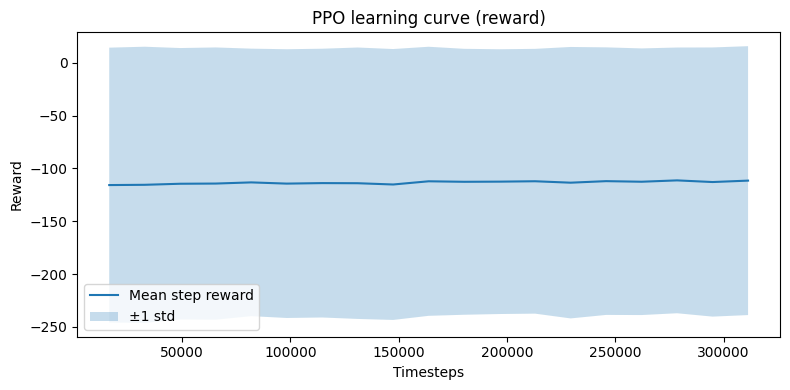

In [4]:
plt.figure(figsize=(8, 4))
plt.plot(df["timesteps"], df["mean_step_reward"], label="Mean step reward")
plt.fill_between(
    df["timesteps"],
    df["mean_step_reward"] - df["std_step_reward"],
    df["mean_step_reward"] + df["std_step_reward"],
    alpha=0.25,
    label="±1 std"
)

plt.xlabel("Timesteps")
plt.ylabel("Reward")
plt.title("PPO learning curve (reward)")
plt.legend()
plt.tight_layout()
plt.show()


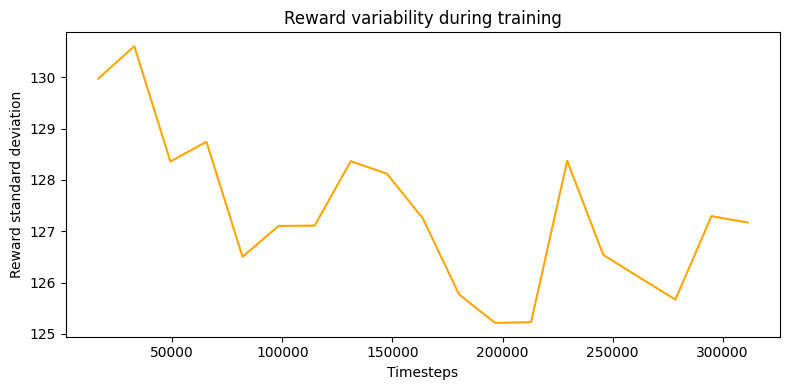

In [5]:
plt.figure(figsize=(8, 4))
plt.plot(df["timesteps"], df["std_step_reward"], color="orange")
plt.xlabel("Timesteps")
plt.ylabel("Reward standard deviation")
plt.title("Reward variability during training")
plt.tight_layout()
plt.show()


In [6]:
action_cols = ["action_0_count", "action_1_count", "action_2_count"]

df_actions = df[action_cols].div(df[action_cols].sum(axis=1), axis=0)
df_actions["timesteps"] = df["timesteps"]

df_actions.head()


,action_0_count,action_1_count,action_2_count,timesteps
0,0.335754,0.333801,0.330444,16384
1,0.328064,0.324402,0.347534,32768
2,0.325134,0.331848,0.343018,49152
3,0.326843,0.325500,0.347656,65536
4,0.313171,0.329895,0.356934,81920


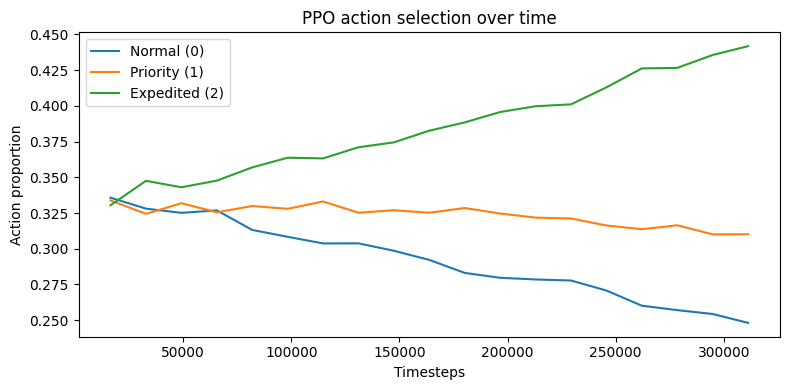

In [7]:
plt.figure(figsize=(8, 4))

plt.plot(df_actions["timesteps"], df_actions["action_0_count"], label="Normal (0)")
plt.plot(df_actions["timesteps"], df_actions["action_1_count"], label="Priority (1)")
plt.plot(df_actions["timesteps"], df_actions["action_2_count"], label="Expedited (2)")

plt.xlabel("Timesteps")
plt.ylabel("Action proportion")
plt.title("PPO action selection over time")
plt.legend()
plt.tight_layout()
plt.show()


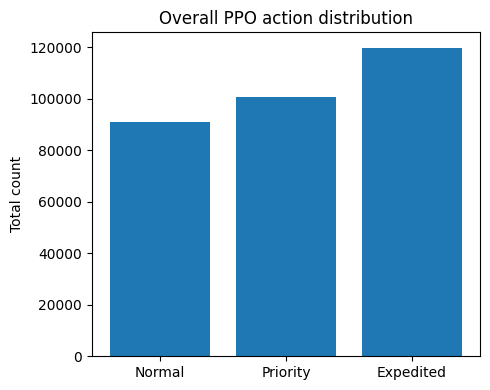

In [8]:
total_actions = df[action_cols].sum()

plt.figure(figsize=(5, 4))
plt.bar(
    ["Normal", "Priority", "Expedited"],
    total_actions.values
)

plt.ylabel("Total count")
plt.title("Overall PPO action distribution")
plt.tight_layout()
plt.show()


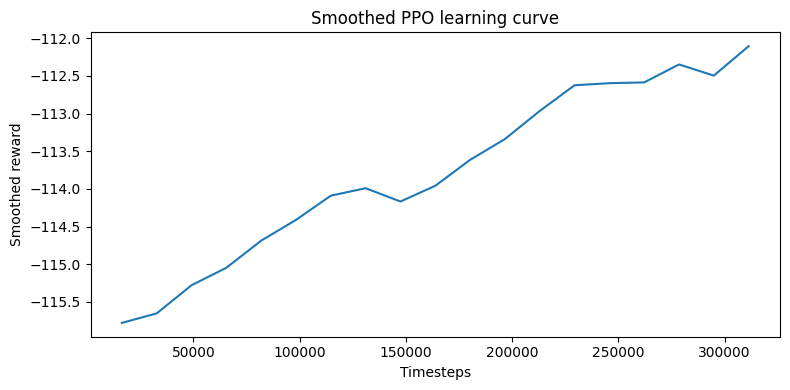

In [9]:
df["reward_smooth"] = df["mean_step_reward"].rolling(window=5, min_periods=1).mean()

plt.figure(figsize=(8, 4))
plt.plot(df["timesteps"], df["reward_smooth"])
plt.xlabel("Timesteps")
plt.ylabel("Smoothed reward")
plt.title("Smoothed PPO learning curve")
plt.tight_layout()
plt.show()
